In [51]:
import os
import sys
import argparse
from pathlib import Path
import numpy as np
import pandas as pd
import geopandas as geopd
import matplotlib.pyplot as plt
import subprocess

## Config

In [52]:
DIR = "/home/dy23a.fsu/st/datasets/raw"
DIR = os.path.join(DIR, "NYC")
TAXI_DIR = Path(DIR) / "taxi"
BIKE_DIR = Path(DIR) / "bike"

FLOW_MODE = "arrival"  # arrival -> dropoff/end ; departure -> pickup/start
assert FLOW_MODE in {"arrival", "departure"}

ZONES_PATH = "./NYC Taxi Zones.geojson"

OUT_DIR = Path(DIR)

BOROUGH_GEOJSON_PATH = "./Manhattan.geojson"
TARGET_BOROUGH = "Manhattan"  # Manhattan / All

In [53]:
YEAR = 2025
FREQ = "15min"
TIME_START = pd.Timestamp(f"{YEAR}-01-01 00:00:00")
TIME_END = pd.Timestamp(f"{YEAR + 1}-01-01 00:00:00")
STEPS = pd.date_range(TIME_START, TIME_END, freq=FREQ, inclusive="left")
T = len(STEPS)
FREQ_TAG = FREQ
print(f"YEAR={YEAR}, FREQ={FREQ}, T={T} steps, FLOW_MODE={FLOW_MODE}")

YEAR=2025, FREQ=15min, T=35040 steps, FLOW_MODE=arrival


## Shapefile and helpers

Region order follows the shapefile (sorted by `LocationID`); all output `(N, T)` arrays use this same order.

In [54]:
zones = geopd.read_file(ZONES_PATH).to_crs("EPSG:4326")
zones = zones.sort_values("LocationID").reset_index(drop=True)
zones["region_idx"] = np.arange(len(zones), dtype=np.int32)
zones_for_join = zones[["region_idx", "geometry"]]
N = len(zones)
bounds = zones.total_bounds
locationid_to_region = {int(loc): idx for idx, loc in enumerate(zones["LocationID"].tolist()) if pd.notna(loc)}
print(f"N={N} regions, bbox={bounds}")

N=263 regions, bbox=[-74.25559136  40.4961154  -73.70000906  40.91553278]


In [55]:
def timestamps_to_step_idx(ts_series):
    ts = pd.to_datetime(ts_series, errors="coerce")
    step = ts.dt.floor(FREQ)
    delta_minutes = (step - TIME_START) / pd.Timedelta(FREQ)
    idx_float = delta_minutes.to_numpy(dtype=np.float64)
    valid = np.isfinite(idx_float) & (idx_float >= 0) & (idx_float < T)
    step_idx = np.zeros(len(idx_float), dtype=np.int64)
    step_idx[valid] = idx_float[valid].astype(np.int64)
    return step_idx, valid

def map_points_to_regions(lon_arr, lat_arr, join_gdf, bounds_):
    minx, miny, maxx, maxy = bounds_
    region_idx = np.full(len(lon_arr), -1, dtype=np.int32)
    in_bbox = (
        (lon_arr >= minx)
        & (lon_arr <= maxx)
        & (lat_arr >= miny)
        & (lat_arr <= maxy)
    )
    if not np.any(in_bbox):
        return region_idx
    candidate_ids = np.where(in_bbox)[0]
    pts = geopd.GeoDataFrame(
        {"row_id": candidate_ids},
        geometry=geopd.points_from_xy(lon_arr[in_bbox], lat_arr[in_bbox]),
        crs="EPSG:4326",
    )
    joined = geopd.sjoin(pts, join_gdf, how="left", predicate="intersects")
    matched = joined.dropna(subset=["region_idx"]).drop_duplicates(subset=["row_id"], keep="first")
    region_idx[matched["row_id"].to_numpy(dtype=np.int64)] = matched["region_idx"].to_numpy(dtype=np.int32)
    return region_idx

def accumulate_nt(region_idx, step_idx, time_valid, nt_matrix):
    valid = time_valid & (region_idx >= 0)
    if not np.any(valid):
        return 0
    flat_idx = region_idx[valid].astype(np.int64) * T + step_idx[valid].astype(np.int64)
    binc = np.bincount(flat_idx, minlength=N * T)
    nt_matrix += binc.reshape(N, T)
    return int(valid.sum())

## Taxi (yellow + green merged)

Both yellow and green files already carry `PULocationID` / `DOLocationID`, so we map them to `region_idx` via the shapefile's `LocationID`.

In [56]:
def process_taxi_parquet(files, schema_map):
    """schema_map: {pattern_prefix: {'pu_id','do_id','pu_time','do_time'}}."""
    import pyarrow.parquet as pq
    nt = np.zeros((N, T), dtype=np.int64)
    total_rows = 0
    kept_rows = 0
    for fp in files:
        prefix = next((k for k in schema_map if fp.name.startswith(k)), None)
        if prefix is None:
            print(f"  skip (no schema): {fp.name}")
            continue
        cols = schema_map[prefix]
        if FLOW_MODE == "arrival":
            loc_col, time_col = cols["do_id"], cols["do_time"]
        else:
            loc_col, time_col = cols["pu_id"], cols["pu_time"]
        print(f"Processing {fp.name} [{loc_col}, {time_col}]")
        pq_file = pq.ParquetFile(fp)
        for rg in range(pq_file.num_row_groups):
            table = pq_file.read_row_group(rg, columns=[loc_col, time_col])
            df = table.to_pandas()
            total_rows += len(df)
            df = df.dropna(subset=[loc_col, time_col])
            if df.empty:
                continue
            loc = pd.to_numeric(df[loc_col], errors="coerce")
            valid_loc = loc.notna()
            if not valid_loc.any():
                continue
            loc = loc[valid_loc].astype(np.int64).reset_index(drop=True)
            ts = df.loc[valid_loc, time_col].reset_index(drop=True)
            region_idx = loc.map(locationid_to_region).fillna(-1).to_numpy(dtype=np.int32)
            step_idx, time_valid = timestamps_to_step_idx(ts)
            kept_rows += accumulate_nt(region_idx, step_idx, time_valid, nt)
    print(f"Rows seen: {total_rows:,}, kept in (N,T): {kept_rows:,}")
    return nt

In [57]:
taxi_schema = {
    "yellow_tripdata": {
        "pu_id": "PULocationID",
        "do_id": "DOLocationID",
        "pu_time": "tpep_pickup_datetime",
        "do_time": "tpep_dropoff_datetime",
    },
    "green_tripdata": {
        "pu_id": "PULocationID",
        "do_id": "DOLocationID",
        "pu_time": "lpep_pickup_datetime",
        "do_time": "lpep_dropoff_datetime",
    },
}
taxi_files = sorted(
    [p for p in TAXI_DIR.glob(f"yellow_tripdata_{YEAR}-*.parquet")] +
    [p for p in TAXI_DIR.glob(f"green_tripdata_{YEAR}-*.parquet")]
)
if not taxi_files:
    raise FileNotFoundError(f"No yellow/green taxi parquet files found under {TAXI_DIR}")
nyc_taxi_nt = process_taxi_parquet(taxi_files, taxi_schema)
taxi_out = OUT_DIR / f"nyc_taxi_{YEAR}_{FREQ_TAG}.npy"
np.save(taxi_out, nyc_taxi_nt)
print(f"Saved {taxi_out} shape={nyc_taxi_nt.shape}, total={nyc_taxi_nt.sum():,}")

Processing green_tripdata_2025-01.parquet [DOLocationID, lpep_dropoff_datetime]
Processing green_tripdata_2025-02.parquet [DOLocationID, lpep_dropoff_datetime]


Processing green_tripdata_2025-03.parquet [DOLocationID, lpep_dropoff_datetime]
Processing green_tripdata_2025-04.parquet [DOLocationID, lpep_dropoff_datetime]
Processing green_tripdata_2025-05.parquet [DOLocationID, lpep_dropoff_datetime]
Processing green_tripdata_2025-06.parquet [DOLocationID, lpep_dropoff_datetime]
Processing green_tripdata_2025-07.parquet [DOLocationID, lpep_dropoff_datetime]
Processing green_tripdata_2025-08.parquet [DOLocationID, lpep_dropoff_datetime]
Processing green_tripdata_2025-09.parquet [DOLocationID, lpep_dropoff_datetime]
Processing green_tripdata_2025-10.parquet [DOLocationID, lpep_dropoff_datetime]
Processing green_tripdata_2025-11.parquet [DOLocationID, lpep_dropoff_datetime]
Processing green_tripdata_2025-12.parquet [DOLocationID, lpep_dropoff_datetime]
Processing yellow_tripdata_2025-01.parquet [DOLocationID, tpep_dropoff_datetime]
Processing yellow_tripdata_2025-02.parquet [DOLocationID, tpep_dropoff_datetime]
Processing yellow_tripdata_2025-03.par

## FHV (fhv + fhvhv merged)

Note: `fhv` parquet uses lower-case `PUlocationID` / `DOlocationID` and `dropOff_datetime`, while `fhvhv` uses `PULocationID` / `DOLocationID`.

In [58]:
fhv_schema = {
    "fhvhv_tripdata": {
        "pu_id": "PULocationID",
        "do_id": "DOLocationID",
        "pu_time": "pickup_datetime",
        "do_time": "dropoff_datetime",
    },
    "fhv_tripdata": {
        "pu_id": "PUlocationID",
        "do_id": "DOlocationID",
        "pu_time": "pickup_datetime",
        "do_time": "dropOff_datetime",
    },
}
# Match longer prefix first so 'fhv_tripdata' doesn't shadow 'fhvhv_tripdata'.
fhv_schema_ordered = {k: fhv_schema[k] for k in sorted(fhv_schema, key=len, reverse=True)}
fhv_files = sorted(
    [p for p in TAXI_DIR.glob(f"fhvhv_tripdata_{YEAR}-*.parquet")] +
    [p for p in TAXI_DIR.glob(f"fhv_tripdata_{YEAR}-*.parquet")]
)
if not fhv_files:
    raise FileNotFoundError(f"No fhv/fhvhv parquet files found under {TAXI_DIR}")
nyc_fhv_nt = process_taxi_parquet(fhv_files, fhv_schema_ordered)
fhv_out = OUT_DIR / f"nyc_fhv_{YEAR}_{FREQ_TAG}.npy"
np.save(fhv_out, nyc_fhv_nt)
print(f"Saved {fhv_out} shape={nyc_fhv_nt.shape}, total={nyc_fhv_nt.sum():,}")

Processing fhv_tripdata_2025-01.parquet [DOlocationID, dropOff_datetime]
Processing fhv_tripdata_2025-02.parquet [DOlocationID, dropOff_datetime]


Processing fhv_tripdata_2025-03.parquet [DOlocationID, dropOff_datetime]
Processing fhv_tripdata_2025-04.parquet [DOlocationID, dropOff_datetime]
Processing fhv_tripdata_2025-05.parquet [DOlocationID, dropOff_datetime]
Processing fhv_tripdata_2025-06.parquet [DOlocationID, dropOff_datetime]
Processing fhv_tripdata_2025-07.parquet [DOlocationID, dropOff_datetime]
Processing fhv_tripdata_2025-08.parquet [DOlocationID, dropOff_datetime]
Processing fhv_tripdata_2025-09.parquet [DOlocationID, dropOff_datetime]
Processing fhv_tripdata_2025-10.parquet [DOlocationID, dropOff_datetime]
Processing fhv_tripdata_2025-11.parquet [DOlocationID, dropOff_datetime]
Processing fhv_tripdata_2025-12.parquet [DOlocationID, dropOff_datetime]
Processing fhvhv_tripdata_2025-01.parquet [DOLocationID, dropoff_datetime]
Processing fhvhv_tripdata_2025-02.parquet [DOLocationID, dropoff_datetime]
Processing fhvhv_tripdata_2025-03.parquet [DOLocationID, dropoff_datetime]
Processing fhvhv_tripdata_2025-04.parquet [DO

## Bike (gps -> shapefile)

Citi Bike CSVs only have lat/lon, so each trip endpoint is spatially joined to a Taxi Zone polygon.

In [59]:
def process_bike_csv(files, chunksize=500_000):
    nt = np.zeros((N, T), dtype=np.int64)
    total_rows = 0
    kept_rows = 0
    if FLOW_MODE == "arrival":
        lon_col, lat_col, time_col = "end_lng", "end_lat", "ended_at"
    else:
        lon_col, lat_col, time_col = "start_lng", "start_lat", "started_at"
    for fp in files:
        print(f"Processing {fp.name}")
        reader = pd.read_csv(
            fp,
            usecols=[lon_col, lat_col, time_col],
            chunksize=chunksize,
            low_memory=False,
        )
        for chunk in reader:
            total_rows += len(chunk)
            chunk = chunk.dropna(subset=[lon_col, lat_col, time_col])
            if chunk.empty:
                continue
            lon = pd.to_numeric(chunk[lon_col], errors="coerce").to_numpy(dtype=np.float64)
            lat = pd.to_numeric(chunk[lat_col], errors="coerce").to_numpy(dtype=np.float64)
            valid_xy = np.isfinite(lon) & np.isfinite(lat)
            if not np.any(valid_xy):
                continue
            lon = lon[valid_xy]
            lat = lat[valid_xy]
            ts = chunk.loc[valid_xy, time_col].reset_index(drop=True)
            step_idx, time_valid = timestamps_to_step_idx(ts)
            region_idx = map_points_to_regions(lon, lat, zones_for_join, bounds)
            kept_rows += accumulate_nt(region_idx, step_idx, time_valid, nt)
    print(f"Rows seen: {total_rows:,}, kept in (N,T): {kept_rows:,}")
    return nt

bike_files = sorted(BIKE_DIR.glob(f"{YEAR}??-citibike-tripdata*.csv"))
if not bike_files:
    raise FileNotFoundError(f"No bike CSV files found under {BIKE_DIR}")
nyc_bike_nt = process_bike_csv(bike_files)
bike_out = OUT_DIR / f"nyc_bike_{YEAR}_{FREQ_TAG}.npy"
np.save(bike_out, nyc_bike_nt)
print(f"Saved {bike_out} shape={nyc_bike_nt.shape}, total={nyc_bike_nt.sum():,}")

Processing 202501-citibike-tripdata_1.csv


Processing 202501-citibike-tripdata_2.csv
Processing 202501-citibike-tripdata_3.csv
Processing 202502-citibike-tripdata_1.csv
Processing 202502-citibike-tripdata_2.csv
Processing 202502-citibike-tripdata_3.csv
Processing 202503-citibike-tripdata_1.csv
Processing 202503-citibike-tripdata_2.csv
Processing 202503-citibike-tripdata_3.csv
Processing 202503-citibike-tripdata_4.csv
Processing 202504-citibike-tripdata_1.csv
Processing 202504-citibike-tripdata_2.csv
Processing 202504-citibike-tripdata_3.csv
Processing 202504-citibike-tripdata_4.csv
Processing 202505-citibike-tripdata_1.csv
Processing 202505-citibike-tripdata_2.csv
Processing 202505-citibike-tripdata_3.csv
Processing 202505-citibike-tripdata_4.csv
Processing 202505-citibike-tripdata_5.csv
Processing 202506-citibike-tripdata_1.csv
Processing 202506-citibike-tripdata_2.csv
Processing 202506-citibike-tripdata_3.csv
Processing 202506-citibike-tripdata_4.csv
Processing 202506-citibike-tripdata_5.csv
Processing 202507-citibike-tripdat

## Summary

In [60]:
def summarize_nt(name, arr):
    arr = np.asarray(arr)
    total = float(arr.sum())
    nnz = int(np.count_nonzero(arr))
    density = 100.0 * nnz / arr.size if arr.size else 0.0
    active_regions = int((arr.sum(axis=1) > 0).sum())
    active_steps = int((arr.sum(axis=0) > 0).sum())
    print(f"[{name}] total={total:,.0f}, nnz={nnz:,} ({density:.3f}%), "
          f"active_regions={active_regions}/{arr.shape[0]}, active_steps={active_steps}/{arr.shape[1]}")

for name, arr in [("taxi", nyc_taxi_nt), ("fhv", nyc_fhv_nt), ("bike", nyc_bike_nt)]:
    summarize_nt(name, arr)

[taxi] total=48,980,075, nnz=4,632,944 (50.273%), active_regions=261/263, active_steps=35036/35040
[fhv] total=252,900,452, nnz=8,593,163 (93.247%), active_regions=263/263, active_steps=35039/35040
[bike] total=45,637,763, nnz=3,887,575 (42.185%), active_regions=153/263, active_steps=35035/35040


## Filter by Borough

If `TARGET_BOROUGH` is set (e.g. `Manhattan`), select the matching rows from each `(N, T)` array using the shapefile index, write `<mobility>_<borough>_<year>_<freq>.npy`, and export the filtered region geojson in the same order.

In [61]:
if TARGET_BOROUGH and str(TARGET_BOROUGH).lower() != "all":
    mask = zones["borough"].astype(str).str.lower() == TARGET_BOROUGH.lower()
    sel_idx = np.where(mask.to_numpy())[0]
    if sel_idx.size == 0:
        raise ValueError(f"No zones found for borough={TARGET_BOROUGH}")
    zones_sel = zones.iloc[sel_idx].reset_index(drop=True)
    borough_tag = TARGET_BOROUGH.lower().replace(" ", "_")
    bgeo_path = OUT_DIR / f"{borough_tag}.geojson"
    zones_sel.drop(columns=["region_idx"], errors="ignore").to_file(bgeo_path, driver="GeoJSON")
    print(f"Borough={TARGET_BOROUGH}, kept {len(sel_idx)}/{N} regions -> {bgeo_path}")
    for name, arr in [("taxi", nyc_taxi_nt), ("fhv", nyc_fhv_nt), ("bike", nyc_bike_nt)]:
        sub = arr[sel_idx]
        out = OUT_DIR / f"nyc_{borough_tag}_{name}_{YEAR}_{FREQ_TAG}.npy"
        np.save(out, sub)
        print(f"  {out} shape={sub.shape}, total={sub.sum():,}")
else:
    sel_idx = np.arange(N)
    zones_sel = zones.copy()
    borough_tag = "all"
    print(f"Borough filter disabled, keeping all {N} regions")

Borough=Manhattan, kept 69/263 regions -> /home/dy23a.fsu/st/datasets/raw/NYC/manhattan.geojson
  /home/dy23a.fsu/st/datasets/raw/NYC/nyc_manhattan_taxi_2025_15min.npy shape=(69, 35040), total=42,470,391
  /home/dy23a.fsu/st/datasets/raw/NYC/nyc_manhattan_fhv_2025_15min.npy shape=(69, 35040), total=84,725,125
  /home/dy23a.fsu/st/datasets/raw/NYC/nyc_manhattan_bike_2025_15min.npy shape=(69, 35040), total=28,656,775


## Merge mobilities

Stack any subset of `["taxi", "fhv", "bike"]` into a single `(M, N, T)` array, where `M` is the number of mobilities chosen. The borough-filtered version uses the same selection.

In [62]:
MERGE_MOBILITIES = ["taxi", "fhv", "bike"]
MOBILITY_ARRS = {"taxi": nyc_taxi_nt, "fhv": nyc_fhv_nt, "bike": nyc_bike_nt}
missing = [m for m in MERGE_MOBILITIES if m not in MOBILITY_ARRS]
if missing:
    raise ValueError(f"Unknown mobilities in MERGE_MOBILITIES: {missing}")

merged = np.stack([MOBILITY_ARRS[m] for m in MERGE_MOBILITIES], axis=1)
merged_tag = "_".join(MERGE_MOBILITIES)
merged_out = OUT_DIR / f"nyc_{merged_tag}_{YEAR}_{FREQ_TAG}.npy"
np.save(merged_out, merged)
print(f"{merged_out} shape={merged.shape} (N,M,T)") 

if TARGET_BOROUGH and str(TARGET_BOROUGH).lower() != "all":
    merged_b = merged[sel_idx, :, :]
    merged_b_out = OUT_DIR / f"nyc_{borough_tag}_{merged_tag}_{YEAR}_{FREQ_TAG}.npy"
    np.save(merged_b_out, merged_b)
    print(f"{merged_b_out} shape={merged_b.shape} (N,M,T)")

/home/dy23a.fsu/st/datasets/raw/NYC/nyc_taxi_fhv_bike_2025_15min.npy shape=(263, 3, 35040) (N,M,T)
/home/dy23a.fsu/st/datasets/raw/NYC/nyc_manhattan_taxi_fhv_bike_2025_15min.npy shape=(69, 3, 35040) (N,M,T)


## Visualization & Sparsity Report

For each mobility (`taxi`, `fhv`, `bike`):
- **Heatmap**: total flow per region painted on the Taxi Zone shapefile (full-city + borough-filtered if `TARGET_BOROUGH` is set).
- **Sparsity report**: zero-rate over `(N,T)`, dead regions, dead steps, per-region/per-step quantiles, daily totals, and weekday × hour-of-day occupancy.

In [63]:
MOBILITY_ARRS_VIZ = {"taxi": nyc_taxi_nt, "fhv": nyc_fhv_nt, "bike": nyc_bike_nt}

def plot_zone_heat(zone_gdf, values, title, cmap="YlOrRd", log=True):
    plot_gdf = zone_gdf.copy()
    vals = np.asarray(values, dtype=np.float64)
    if log:
        plot_gdf["flow"] = np.log1p(vals)
        legend_label = "log1p(total flow)"
    else:
        plot_gdf["flow"] = vals
        legend_label = "total flow"
    fig, ax = plt.subplots(1, 1, figsize=(8, 8))
    plot_gdf.plot(
        column="flow",
        cmap=cmap,
        linewidth=0.2,
        edgecolor="black",
        legend=True,
        legend_kwds={"label": legend_label, "shrink": 0.6},
        ax=ax,
    )
    ax.set_title(title)
    ax.set_axis_off()
    plt.tight_layout()
    plt.show()

def sparsity_report(name, arr, time_index):
    arr = np.asarray(arr)
    total_cells = arr.size
    nnz = int(np.count_nonzero(arr))
    zero_rate = 1.0 - nnz / total_cells if total_cells else 0.0
    total_flow = float(arr.sum())
    region_sum = arr.sum(axis=1)
    step_sum = arr.sum(axis=0)
    dead_regions = int((region_sum == 0).sum())
    dead_steps = int((step_sum == 0).sum())
    region_q = np.quantile(region_sum, [0.0, 0.25, 0.5, 0.75, 1.0])
    step_q = np.quantile(step_sum, [0.0, 0.25, 0.5, 0.75, 1.0])
    nz_step_q = np.quantile(step_sum[step_sum > 0], [0.25, 0.5, 0.75]) if (step_sum > 0).any() else np.array([0, 0, 0])
    print(f"=== Sparsity report: {name} ===")
    print(f"  shape={arr.shape}, total_flow={total_flow:,.0f}")
    print(f"  nnz cells={nnz:,}/{total_cells:,}  zero_rate={zero_rate*100:.3f}%")
    print(f"  dead regions={dead_regions}/{arr.shape[0]}  dead steps={dead_steps}/{arr.shape[1]}")
    print(f"  region totals  min/Q1/med/Q3/max = {region_q[0]:,.0f} / {region_q[1]:,.0f} / {region_q[2]:,.0f} / {region_q[3]:,.0f} / {region_q[4]:,.0f}")
    print(f"  step totals    min/Q1/med/Q3/max = {step_q[0]:,.0f} / {step_q[1]:,.0f} / {step_q[2]:,.0f} / {step_q[3]:,.0f} / {step_q[4]:,.0f}")
    print(f"  step totals  (non-zero only) Q1/med/Q3 = {nz_step_q[0]:,.0f} / {nz_step_q[1]:,.0f} / {nz_step_q[2]:,.0f}")
    idx_active = np.where(step_sum > 0)[0]
    if idx_active.size:
        print(f"  first_active={pd.Timestamp(time_index[idx_active[0]])}, last_active={pd.Timestamp(time_index[idx_active[-1]])}")

def plot_temporal_panels(name, arr, time_index):
    arr = np.asarray(arr)
    ts = pd.to_datetime(time_index)
    series = pd.Series(arr.sum(axis=0), index=ts)
    daily = series.resample("D").sum()
    hod = pd.DataFrame({"flow": series.values}, index=ts)
    hod["dow"] = hod.index.dayofweek
    hod["hour"] = hod.index.hour
    pivot = hod.pivot_table(index="dow", columns="hour", values="flow", aggfunc="sum").reindex(index=range(7), columns=range(24))
    fig, axes = plt.subplots(1, 2, figsize=(15, 4))
    axes[0].plot(daily.index, daily.values, linewidth=1.2)
    axes[0].set_title(f"{name} - daily total flow")
    axes[0].set_xlabel("Date")
    axes[0].set_ylabel("Daily total flow")
    axes[0].grid(alpha=0.25)
    im = axes[1].imshow(pivot.values, aspect="auto", cmap="viridis", origin="lower")
    axes[1].set_title(f"{name} - weekday x hour total flow")
    axes[1].set_xlabel("Hour of day")
    axes[1].set_ylabel("Day of week (0=Mon)")
    axes[1].set_xticks(range(0, 24, 3))
    axes[1].set_yticks(range(7))
    axes[1].set_yticklabels(["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"])
    fig.colorbar(im, ax=axes[1], shrink=0.8, label="flow")
    plt.tight_layout()
    plt.show()

=== Sparsity report: taxi ===
  shape=(263, 35040), total_flow=48,980,075
  nnz cells=4,632,944/9,215,520  zero_rate=49.727%
  dead regions=2/263  dead steps=4/35040
  region totals  min/Q1/med/Q3/max = 0 / 9,746 / 24,234 / 130,540 / 1,970,258
  step totals    min/Q1/med/Q3/max = 0 / 687 / 1,539 / 1,951 / 3,848
  step totals  (non-zero only) Q1/med/Q3 = 687 / 1,539 / 1,951
  first_active=2025-01-01 00:00:00, last_active=2025-12-31 23:45:00


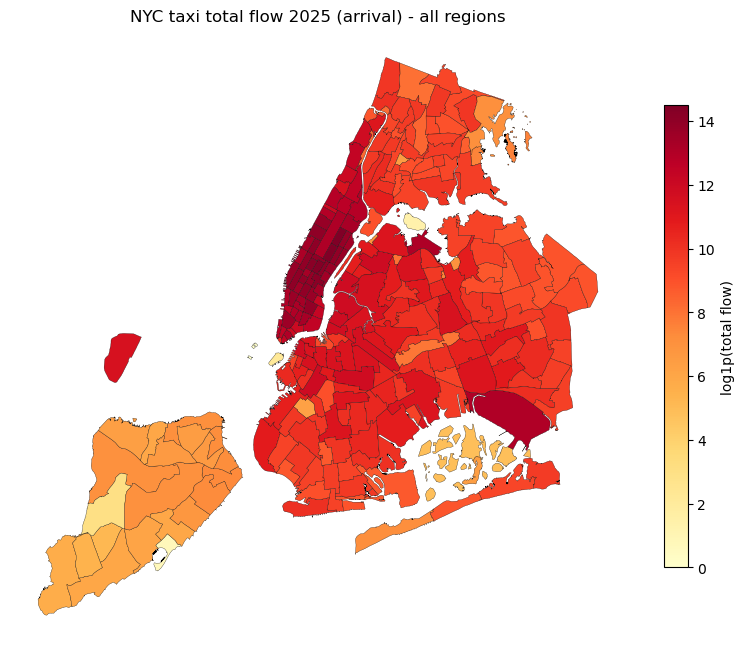

=== Sparsity report: taxi [Manhattan] ===
  shape=(69, 35040), total_flow=42,470,391
  nnz cells=2,025,130/2,417,760  zero_rate=16.239%
  dead regions=2/69  dead steps=4/35040
  region totals  min/Q1/med/Q3/max = 0 / 222,907 / 507,308 / 961,665 / 1,970,258
  step totals    min/Q1/med/Q3/max = 0 / 533 / 1,344 / 1,718 / 3,497
  step totals  (non-zero only) Q1/med/Q3 = 533 / 1,344 / 1,718
  first_active=2025-01-01 00:00:00, last_active=2025-12-31 23:45:00


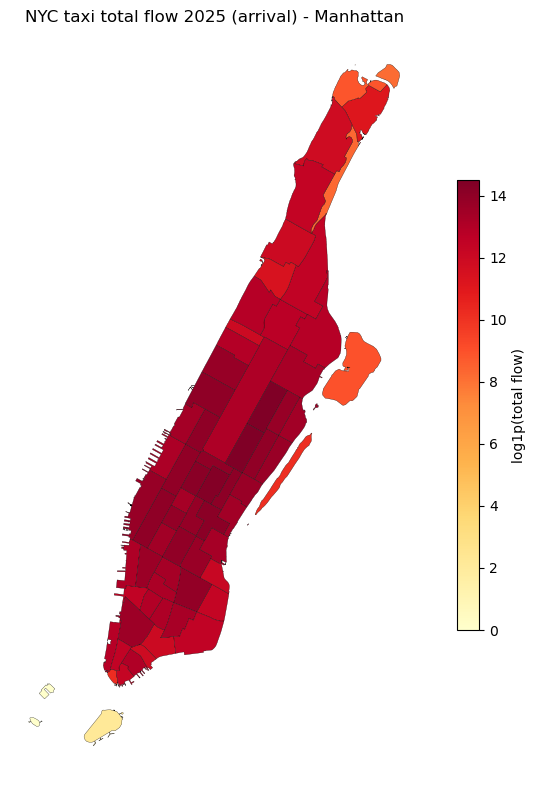

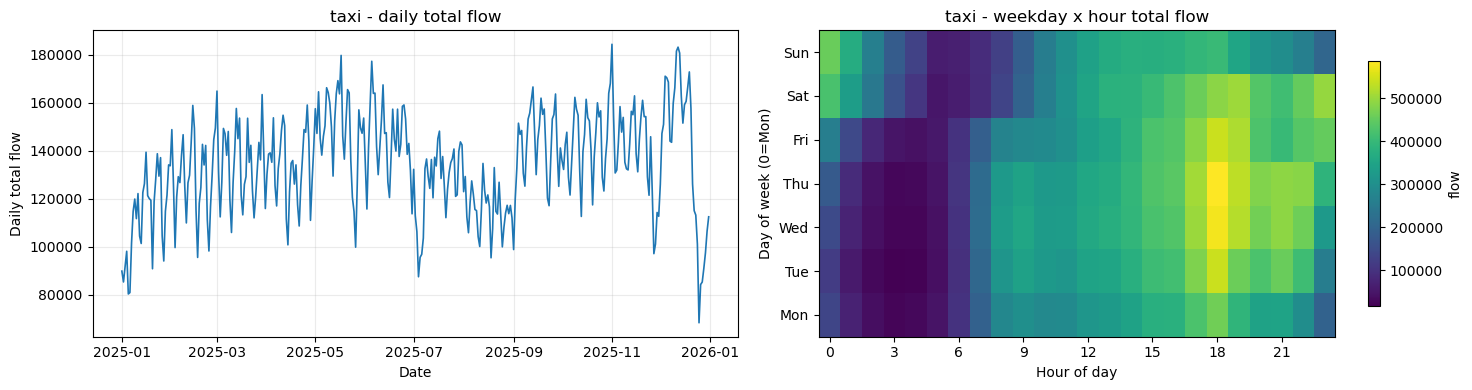

=== Sparsity report: fhv ===
  shape=(263, 35040), total_flow=252,900,452
  nnz cells=8,593,163/9,215,520  zero_rate=6.753%
  dead regions=0/263  dead steps=1/35040
  region totals  min/Q1/med/Q3/max = 1 / 346,567 / 780,564 / 1,397,127 / 5,433,573
  step totals    min/Q1/med/Q3/max = 0 / 5,012 / 7,872 / 9,192 / 21,492
  step totals  (non-zero only) Q1/med/Q3 = 5,012 / 7,872 / 9,192
  first_active=2025-01-01 00:00:00, last_active=2025-12-31 23:45:00


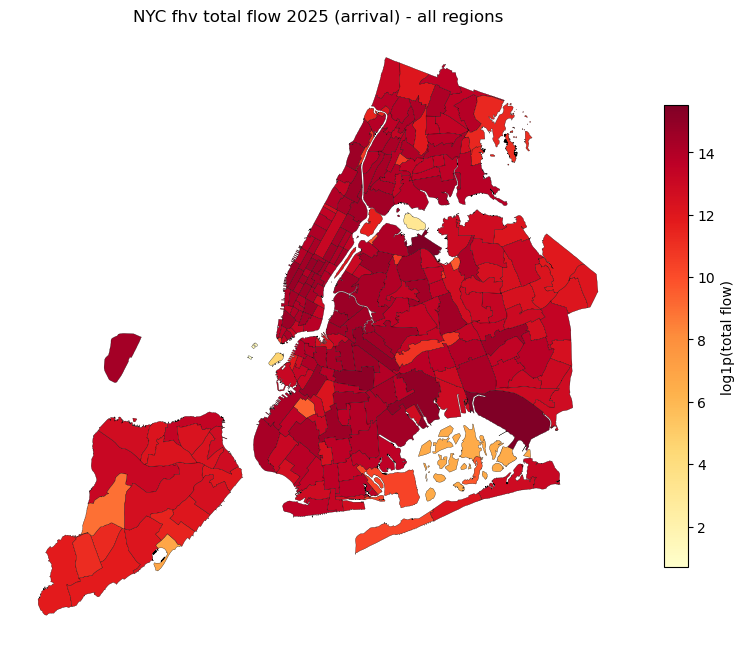

=== Sparsity report: fhv [Manhattan] ===
  shape=(69, 35040), total_flow=84,725,125
  nnz cells=2,252,887/2,417,760  zero_rate=6.819%
  dead regions=0/69  dead steps=4/35040
  region totals  min/Q1/med/Q3/max = 1 / 647,156 / 1,203,817 / 1,799,445 / 2,535,385
  step totals    min/Q1/med/Q3/max = 0 / 1,523 / 2,614 / 3,173 / 7,995
  step totals  (non-zero only) Q1/med/Q3 = 1,524 / 2,614 / 3,173
  first_active=2025-01-01 00:00:00, last_active=2025-12-31 23:45:00


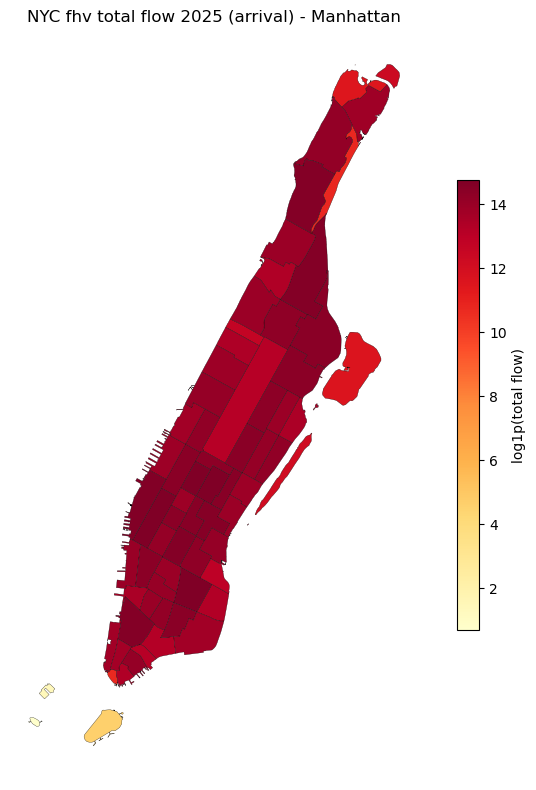

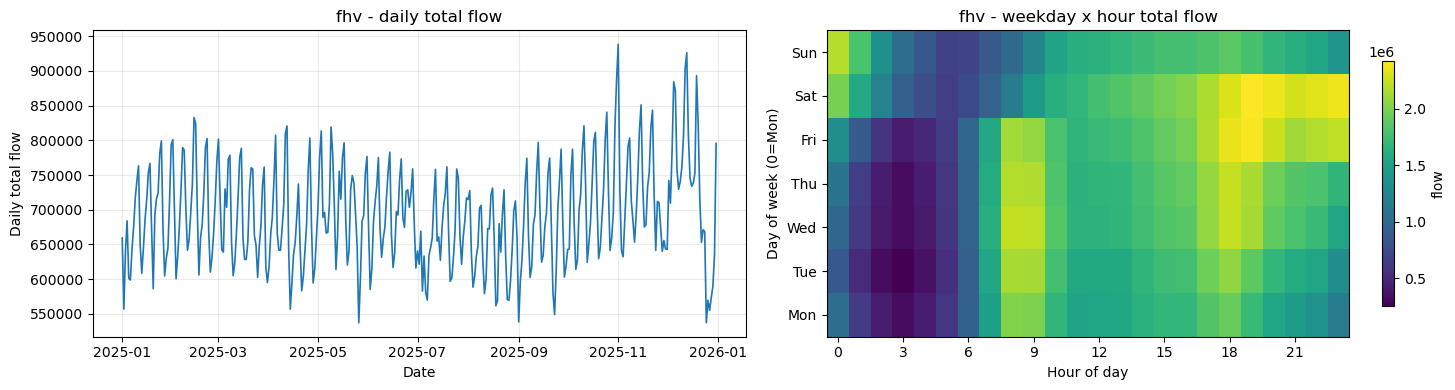

=== Sparsity report: bike ===
  shape=(263, 35040), total_flow=45,637,763
  nnz cells=3,887,575/9,215,520  zero_rate=57.815%
  dead regions=110/263  dead steps=5/35040
  region totals  min/Q1/med/Q3/max = 0 / 0 / 28,439 / 282,775 / 1,870,308
  step totals    min/Q1/med/Q3/max = 0 / 362 / 1,104 / 1,961 / 5,453
  step totals  (non-zero only) Q1/med/Q3 = 362 / 1,104 / 1,961
  first_active=2025-01-01 00:00:00, last_active=2025-12-31 23:45:00


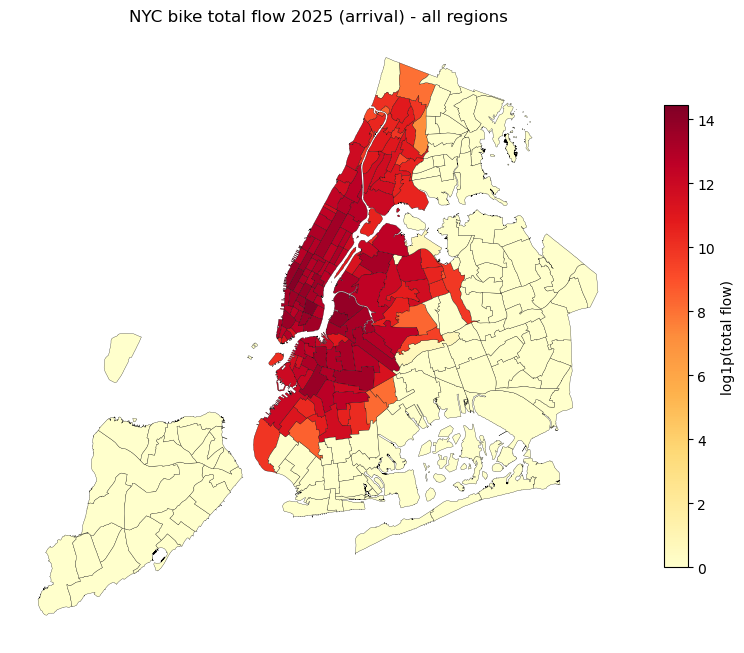

=== Sparsity report: bike [Manhattan] ===
  shape=(69, 35040), total_flow=28,656,775
  nnz cells=1,906,149/2,417,760  zero_rate=21.161%
  dead regions=2/69  dead steps=5/35040
  region totals  min/Q1/med/Q3/max = 0 / 151,613 / 356,531 / 539,390 / 1,870,308
  step totals    min/Q1/med/Q3/max = 0 / 211 / 676 / 1,248 / 3,590
  step totals  (non-zero only) Q1/med/Q3 = 211 / 676 / 1,248
  first_active=2025-01-01 00:00:00, last_active=2025-12-31 23:45:00


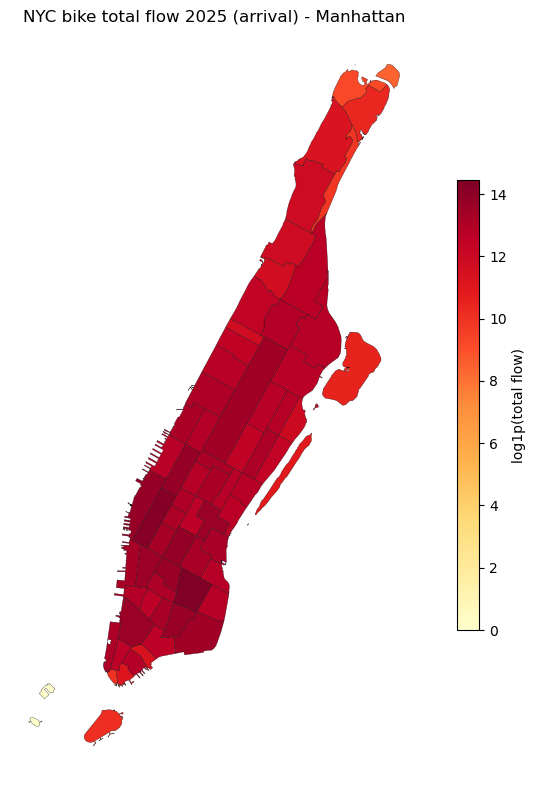

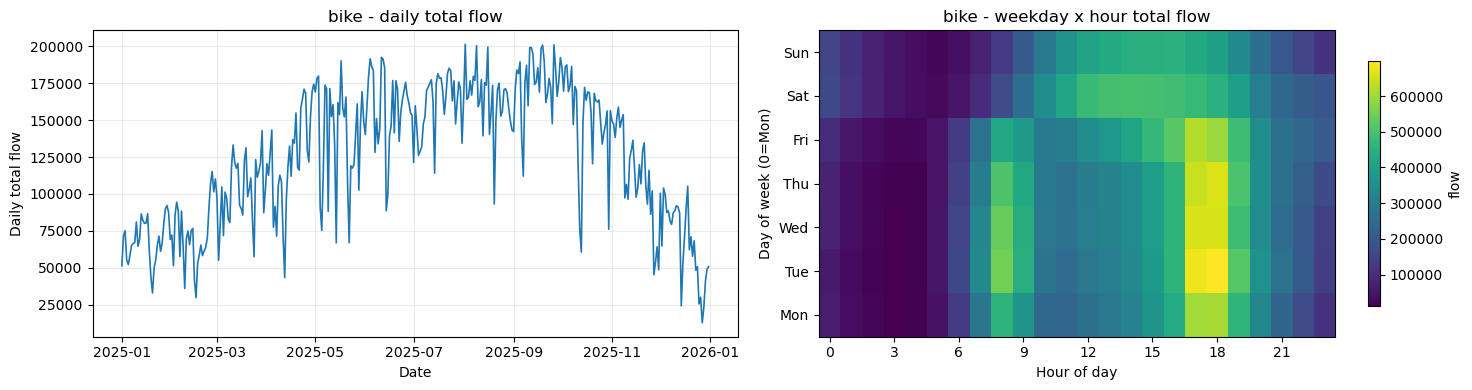

In [64]:
borough_active = bool(TARGET_BOROUGH and str(TARGET_BOROUGH).lower() != "all")
for name, arr in MOBILITY_ARRS_VIZ.items():
    sparsity_report(name, arr, STEPS)
    plot_zone_heat(zones, arr.sum(axis=1), f"NYC {name} total flow {YEAR} ({FLOW_MODE}) - all regions")
    if borough_active:
        sub = arr[sel_idx]
        sparsity_report(f"{name} [{TARGET_BOROUGH}]", sub, STEPS)
        plot_zone_heat(zones_sel, sub.sum(axis=1), f"NYC {name} total flow {YEAR} ({FLOW_MODE}) - {TARGET_BOROUGH}")
    plot_temporal_panels(name, arr, STEPS)

In [69]:
if TARGET_BOROUGH and str(TARGET_BOROUGH).lower() != "all":
    src_path = OUT_DIR / f"nyc_{borough_tag}_{merged_tag}_{YEAR}_{FREQ_TAG}.npy"
    DATASET = "nyc_manhattan_15min"
else:
    src_path = OUT_DIR / f"nyc_{merged_tag}_{YEAR}_{FREQ_TAG}.npy"
    DATASET = "nyc"

merged_arr = np.load(src_path)
M = len(MERGE_MOBILITIES)
if merged_arr.shape[0] == M and merged_arr.shape[1] != M:
    ndt = merged_arr.transpose(1, 0, 2)   # (M, N, T) -> (N, D, T)
elif merged_arr.shape[1] == M:
    ndt = merged_arr                       # already (N, D, T)
else:
    raise ValueError(f"Cannot locate mobility axis (M={M}) in {merged_arr.shape}")
ndt_path = src_path.with_name(src_path.stem + "_NDT.npy")
np.save(ndt_path, ndt)
print(f"{ndt_path} shape={tuple(ndt.shape)} (N, D, T) with D={M} mobilities")

subprocess.run([
    "python3", "/home/dy23a.fsu/st/utils/generate.py",
    "--data_path", str(ndt_path),
    "--fmt", "NDT",
    "--clip_neg",
    "--per_channel",
    "--log1p",
    "--dataset", DATASET,
    "--years", str(YEAR),
    "--seq_length_x", "12",
    "--seq_length_y", "1",
], check=True)

/home/dy23a.fsu/st/datasets/raw/NYC/nyc_manhattan_taxi_fhv_bike_2025_15min_NDT.npy shape=(69, 3, 35040) (N, D, T) with D=3 mobilities


Loaded /home/dy23a.fsu/st/datasets/raw/NYC/nyc_manhattan_taxi_fhv_bike_2025_15min_NDT.npy, raw shape: (69, 3, 35040)
Clipped negative values to 0
Reordered NDT → TND, shape: (35040, 69, 3)
Raw — max: 583, min: 0, mean: 21.4871, std: 26.3729
Index range: [11, 35039), total=35028, train=28022, val=3503, test=3503
MinMaxScaler(log1p=True) min: [0.0, 0.0, 0.0], max: [5.700443744659424, 6.369901180267334, 5.627621173858643]
Normalized — max: 1.0000, min: 0.0000, mean: 0.3912, std: 0.2328
Saved meta.json to /blue/gtyson.fsu/dy23a.fsu/datasets/nyc_manhattan_15min/2025/meta.json
Saved to /blue/gtyson.fsu/dy23a.fsu/datasets/nyc_manhattan_15min/2025
Saved info.json to /blue/gtyson.fsu/dy23a.fsu/datasets/nyc_manhattan_15min/2025/info.json


CompletedProcess(args=['python3', '/home/dy23a.fsu/st/utils/generate.py', '--data_path', '/home/dy23a.fsu/st/datasets/raw/NYC/nyc_manhattan_taxi_fhv_bike_2025_15min_NDT.npy', '--fmt', 'NDT', '--clip_neg', '--per_channel', '--log1p', '--dataset', 'nyc_manhattan_15min', '--years', '2025', '--seq_length_x', '12', '--seq_length_y', '1'], returncode=0)

In [70]:
sys.path.insert(0, "/home/dy23a.fsu/st/utils")
from get_adj_mat import get_adjacency_matrix

if TARGET_BOROUGH and str(TARGET_BOROUGH).lower() != "all":
    ADJ_OUT = Path("/home/dy23a.fsu/st/datasets") / "nyc_manhattan_15min" / "Manhattan.npy"
    ADJ_OUT.parent.mkdir(parents=True, exist_ok=True)
    ctr = zones_sel.set_geometry("geometry").centroid.reset_index(drop=True)
    N_adj = len(ctr)
    ids = list(range(N_adj))
    distance = [[i, j, ctr[i].distance(ctr[j])] for i in ids for j in ids]
    adj_mx = get_adjacency_matrix(distance_df=distance, sensor_ids=ids)
    np.save(ADJ_OUT, adj_mx)
    print(f"Saved {ADJ_OUT} shape={adj_mx.shape}")

else:
    ADJ_OUT = Path("/home/dy23a.fsu/st/datasets") / "nyc_15min" / "nyc.npy"
    ADJ_OUT.parent.mkdir(parents=True, exist_ok=True)
    ctr = zones.set_geometry("geometry").centroid.reset_index(drop=True)
    N_adj = len(ctr)
    ids = list(range(N_adj))
    distance = [[i, j, ctr[i].distance(ctr[j])] for i in ids for j in ids]
    adj_mx = get_adjacency_matrix(distance_df=distance, sensor_ids=ids)
    np.save(ADJ_OUT, adj_mx)
    print(f"Saved {ADJ_OUT} shape={adj_mx.shape}")

Saved /home/dy23a.fsu/st/datasets/nyc_manhattan_15min/Manhattan.npy shape=(69, 69)


/scratch/local/35320171/ipykernel_4064784/1904212056.py:7: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  ctr = zones_sel.set_geometry("geometry").centroid.reset_index(drop=True)
